                         chart     HHI
0              Australia Songs  0.0848
1                Austria Songs  0.0816
2                Belgium Songs  0.0784
3     Billboard Arabic Hot 100  0.0592
4  Billboard Argentina Hot 100  0.0880


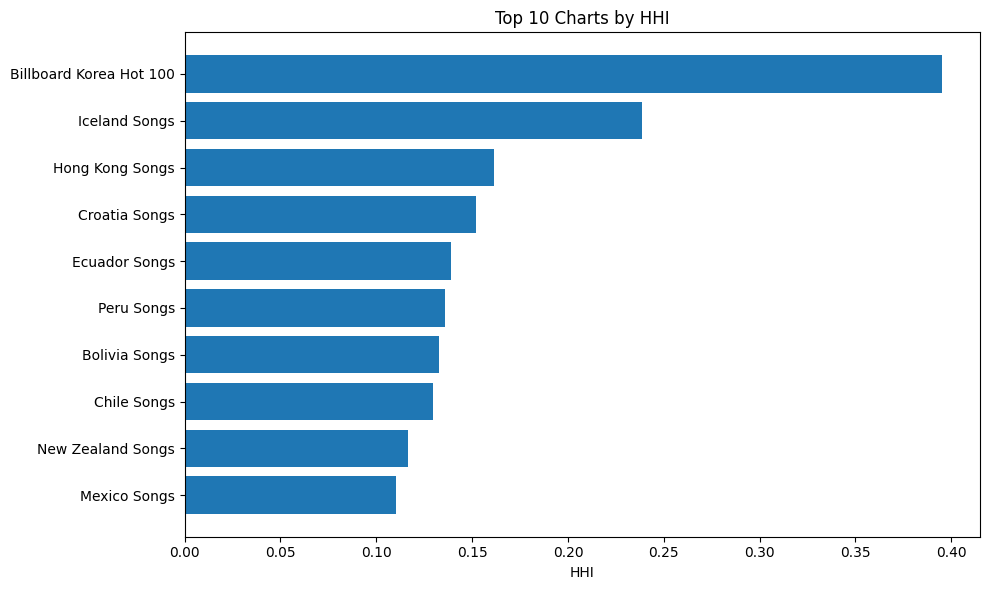

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("all_data/hhi_country.csv")
print(df.head())

top10 = df.sort_values("HHI", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["chart"], top10["HHI"])
plt.xlabel("HHI")
plt.title("Top 10 Charts by HHI")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

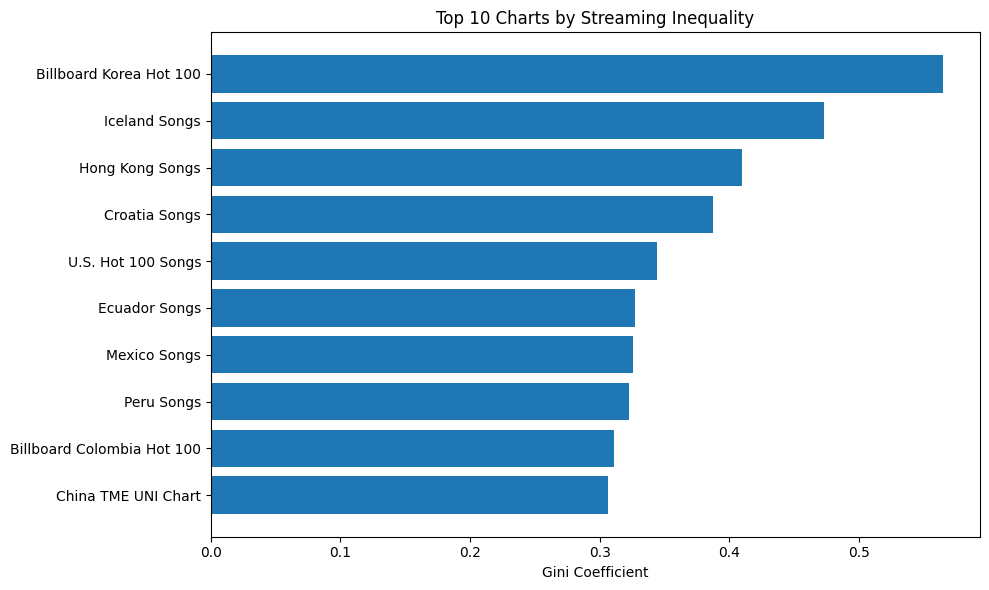

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("all_data/gini_country.csv")

top10 = df.sort_values("Gini", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["chart"], top10["Gini"])
plt.xlabel("Gini Coefficient")
plt.title("Top 10 Charts by Streaming Inequality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

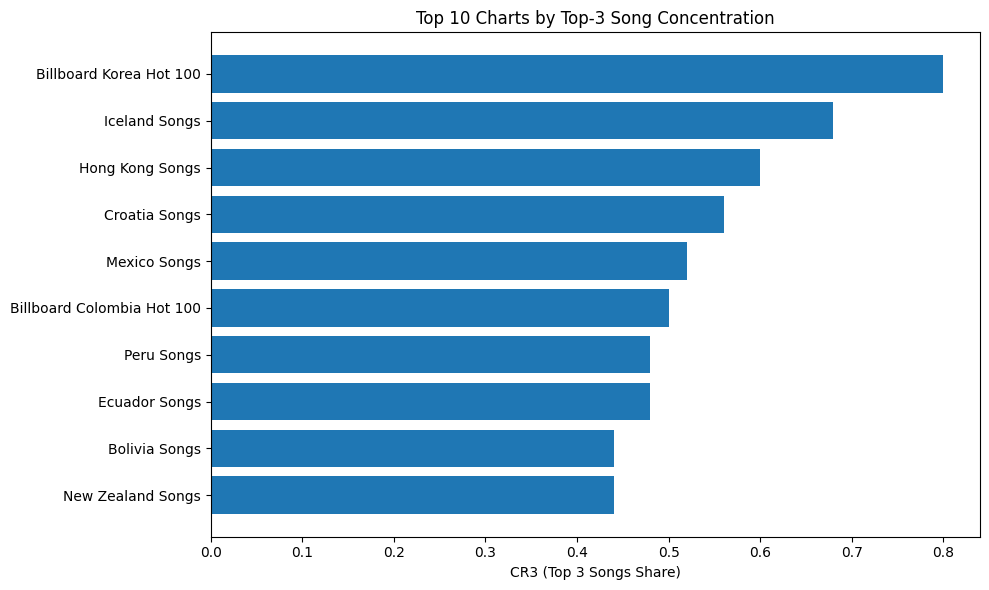

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("all_data/cr3_country.csv")

top10 = df.sort_values("CR3", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["chart"], top10["CR3"])
plt.xlabel("CR3 (Top 3 Songs Share)")
plt.title("Top 10 Charts by Top-3 Song Concentration")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("all_data/data.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

tables

,name
0,BillboardCharts
1,IndividualArtistMentions
2,SongArtistMentions
3,SongArtistChartAppearances
4,SpotifyDailyStreamingCharts
5,SpotifyWeeklyStreamingCharts
6,AppleChartRankings


In [11]:
pd.read_sql("SELECT * FROM BillboardCharts LIMIT 10", conn)

,artist,song_name,rank,artist_link,last_week_rank,peak,weeks_chart,week,chart
0,Flipperachi,FA9LA,1,None,1,1,10,02-28-2026,Billboard Arabic Hot 100
1,DYSTINCT,Yama,2,None,2,1,17,02-28-2026,Billboard Arabic Hot 100
2,Vanco Featuring AYA,Ma Tnsani,3,None,3,2,29,02-28-2026,Billboard Arabic Hot 100
3,"Lege-Cy, Ghaliaa",Msh Awl Marra,4,None,7,4,3,02-28-2026,Billboard Arabic Hot 100
4,DYSTINCT,Ta3al,5,None,4,3,4,02-28-2026,Billboard Arabic Hot 100
5,Sherine Abdel Wahab,Batmanna Ansak,6,None,5,5,35,02-28-2026,Billboard Arabic Hot 100
6,TUL8TE,El Hob Gany,7,None,6,2,19,02-28-2026,Billboard Arabic Hot 100
7,"Saint Levant, Marwan Moussa",KALAMANTINA,8,None,8,2,52,02-28-2026,Billboard Arabic Hot 100
8,"Nassif Zeytoun, Abu Ward",Kazdoura,9,None,9,3,9,02-28-2026,Billboard Arabic Hot 100
9,TUL8TE,Heseeny,10,None,11,9,28,02-28-2026,Billboard Arabic Hot 100


In [12]:
pd.read_sql("SELECT * FROM SpotifyWeeklyStreamingCharts LIMIT 10", conn)

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
0,1,Bad Bunny,DtMF,1,60,45722046,-14850248.0,1549114511,Spotify Weekly Chart Global,02-26-2026,Global
1,2,Bad Bunny,BAILE INoLVIDABLE,2,60,33278386,-10608661.0,1273769628,Spotify Weekly Chart Global,02-26-2026,Global
2,3,Djo,End of Beginning,1,106,32979053,-2245987.0,2225140553,Spotify Weekly Chart Global,02-26-2026,Global
3,4,Bad Bunny,NUEVAYoL,3,60,32180613,-10955089.0,1040380429,Spotify Weekly Chart Global,02-26-2026,Global
4,5,Olivia Dean,Man I Need,3,27,31180371,-1623349.0,792309416,Spotify Weekly Chart Global,02-26-2026,Global
5,6,Taylor Swift,The Fate of Ophelia,1,21,30757410,-1642037.0,1067922884,Spotify Weekly Chart Global,02-26-2026,Global
6,7,Bad Bunny,Tití Me Preguntó,4,65,29191815,-10571027.0,1353700358,Spotify Weekly Chart Global,02-26-2026,Global
7,8,Olivia Dean,So Easy (To Fall In Love),6,22,28614470,-42457.0,511942011,Spotify Weekly Chart Global,02-26-2026,Global
8,9,sombr,back to friends,1,49,26755674,-790110.0,1507193317,Spotify Weekly Chart Global,02-26-2026,Global
9,10,Bad Bunny,EoO,4,60,26351243,-8419061.0,921635016,Spotify Weekly Chart Global,02-26-2026,Global


In [13]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,BillboardCharts
1,IndividualArtistMentions
2,SongArtistMentions
3,SongArtistChartAppearances
4,SpotifyDailyStreamingCharts
5,SpotifyWeeklyStreamingCharts
6,AppleChartRankings


In [14]:
global_songs = pd.read_sql("""
SELECT song_name, artist, rank
FROM BillboardCharts
WHERE chart = 'Worldwide Top 200 Songs'
AND rank <= 10
ORDER BY rank
""", conn)

global_songs

,song_name,artist,rank
0,DTMF,Bad Bunny,1
1,Baile Inolvidable,Bad Bunny,2
2,Nuevayol,Bad Bunny,3
3,Titi Me Pregunto,Bad Bunny,4
4,Man I Need,Olivia Dean,5
5,The Fate Of Ophelia,Taylor Swift,6
6,Golden,"HUNTR/X: EJAE, Audrey Nuna & REI AMI",7
7,Ordinary,Alex Warren,8
8,EOO,Bad Bunny,9
9,End Of Beginning,Djo,10


## Python Function to generate maps ##

In [15]:
def get_song_by_rank(conn, rank):
    query = f"""
    SELECT song_name, artist, rank
    FROM BillboardCharts
    WHERE chart = 'Worldwide Top 200 Songs'
      AND rank = {rank}
    LIMIT 1
    """
    result = pd.read_sql(query, conn)
    if result.empty:
        raise ValueError(f"No song found for rank {rank}")
    return result.iloc[0]["song_name"], result.iloc[0]["artist"]

In [16]:
def get_song_views(conn, population_df, rank=None, song_name=None, artist=None):
    """
    Returns:
        spotify_df: weekly Spotify streams by country
        apple_df: Apple Music rankings by country
        normalized_df: Spotify streams merged with population and streams_per_million
    """

    # If rank is given, get song_name and artist from Billboard
    if rank is not None:
        song_name, artist = get_song_by_rank(conn, rank)

    # Validate input
    if song_name is None or artist is None:
        raise ValueError("Provide either rank OR both song_name and artist")

    # Spotify weekly streams by country
    spotify_query = f"""
    SELECT country, SUM(Streams) AS weekly_streams
    FROM SpotifyWeeklyStreamingCharts
    WHERE country <> 'Global'
      AND LOWER(song_name) = LOWER('{song_name}')
      AND LOWER(artist) = LOWER('{artist}')
    GROUP BY country
    ORDER BY weekly_streams DESC
    """
    spotify_df = pd.read_sql(spotify_query, conn)

    # Apple Music rank by country
    apple_query = f"""
    SELECT country, rank AS apple_rank
    FROM AppleChartRankings
    WHERE LOWER(song_name) = LOWER('{song_name}')
      AND LOWER(artist) = LOWER('{artist}')
    ORDER BY apple_rank ASC
    """
    apple_df = pd.read_sql(apple_query, conn)

    # Normalize Spotify streams by population
    normalized_df = spotify_df.merge(population_df, on="country", how="left")
    normalized_df["streams_per_million"] = (
        normalized_df["weekly_streams"] / normalized_df["population"]
    ) * 1_000_000

    return {
        "song_name": song_name,
        "artist": artist,
        "spotify": spotify_df,
        "apple": apple_df,
        "normalized": normalized_df
    }

In [17]:
views = get_song_views(conn, population_df, rank=10)

print(views["song_name"], "-", views["artist"])
views["spotify"].head()
views["apple"].head()
views["normalized"].head()

NameError: name 'population_df' is not defined

In [109]:
views = get_song_views(
    conn,
    population_df,
    song_name="DTMF",
    artist="Bad Bunny"
)

In [110]:
def plot_spotify_map(song_views):
    df = song_views["spotify"]
    song_name = song_views["song_name"]

    fig = px.choropleth(
        df,
        locations="country",
        locationmode="country names",
        color="weekly_streams",
        hover_name="country",
        hover_data={"weekly_streams": True},
        title=f"Weekly Spotify Streams for '{song_name}'",
        color_continuous_scale="Purples"
    )
    fig.show()

In [111]:
def plot_apple_map(song_views):
    df = song_views["apple"]
    song_name = song_views["song_name"]

    fig = px.choropleth(
        df,
        locations="country",
        locationmode="country names",
        color="apple_rank",
        hover_name="country",
        hover_data={"apple_rank": True},
        title=f"Apple Music Rankings for '{song_name}'",
        color_continuous_scale="Blues_r"
    )
    fig.show()

In [112]:
def plot_normalized_map(song_views):
    df = song_views["normalized"]
    song_name = song_views["song_name"]

    fig = px.choropleth(
        df,
        locations="country",
        locationmode="country names",
        color="streams_per_million",
        hover_name="country",
        hover_data={
            "weekly_streams": True,
            "population": True,
            "streams_per_million": True
        },
        title=f"Spotify Streams per Million People for '{song_name}'",
        color_continuous_scale="Greens"
    )
    fig.show()

In [113]:
views = get_song_views(conn, population_df, rank=1)

plot_spotify_map(views)
plot_apple_map(views)
plot_normalized_map(views)

/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/1390849077.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/2973962620.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/319837488.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure 

In [114]:
views10 = get_song_views(
    conn,
    population_df,
    song_name="End Of Beginning",
    artist="Djo"
)

plot_spotify_map(views10)
plot_apple_map(views10)
plot_normalized_map(views10)

/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/1390849077.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/2973962620.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/319837488.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure 

In [115]:
views15 = get_song_views(
    conn,
    population_df,
    song_name="I Just Might",
    artist="Bruno Mars"
)

plot_spotify_map(views15)
plot_apple_map(views15)
plot_normalized_map(views15)

/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/1390849077.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/2973962620.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
/var/folders/kk/k_8pw65x39q53y8bmjmbqkn00000gn/T/ipykernel_40294/319837488.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure 